### Structured Light

This example discusses helper functions and details for manipulating phase patterns:
mainly regarding the contents of `slmsuite.holography.toolbox.phase`. 

#### Initialization

This tutorial can be run optionally with or without hardware connected. The below code block tries to load physical hardware and cleanly falls back to virtual hardware if loading fails.

In [1]:
# Header. This is hidden from sphinx with the json metadata:
#   {"nbsphinx":"hidden"}

# ipython configuration (reloads source code automatically and plots inline)
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os, sys
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rc('image', cmap='inferno')

[INF] 21:08:18 PLM Initialized PLM on display 2.
[INF] 21:08:22 FLIR Cam Initialized FLIR.
[WRN] 21:08:23 FLIR Cam Attempted to set WOI to (2148, 1024, 1004, 1024), but realized (2148, 1024, 1000, 1024).
[INF] 21:08:23 FLIR Cam-PLM Initialized FourierSLM.
[INF] 21:08:23 FLIR Cam-PLM Loaded 'pixel' calibration from 'slm2_pixel_calibration_1-5V.h5'.
[INF] 21:08:23 FLIR Cam-PLM Loaded 'wavefront' calibration from 'slm2_superpixel_calibration_offset=0-25_wav=488.h5'.
[WRN] 21:08:23 FLIR Cam-PLM remove_background is enabled and a noise floor was detected; removing this background (4.2% of the average normalization).


smooth: 100%|██████████| 16/16 [00:00<00:00, 31.50it/s]


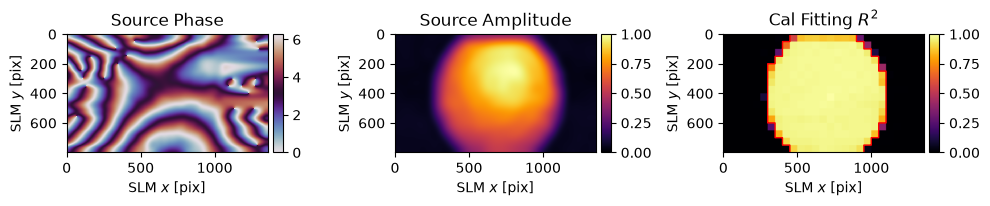

In [2]:
# Try to load physical hardware.
from slmsuite.hardware.cameraslms import FourierSLM

try:
    from slmsuite.hardware.slms.texasinstruments import PLM
    from slmsuite.hardware.cameras.flir import FLIR

    # Load the hardware.
    slm = PLM(
        'p67',
        display_number=2,
        configure_usb=True,
        usb_device_number=1,
        wav_um=0.488,
        settle_time_s=0.05,
        name='PLM',
    )

    cam = FLIR(
        serial="22562470",
        pitch_um=2.74,
        bitdepth=12,
        name="FLIR Cam"
    )

    # For this camera, we also want to crop the WOI to the center 1024x1024 area.
    cam.set_woi((1024, 1024))       # (w, h) centers the WOI on the sensor.

    # Load the composite CameraSLM.
    fs = FourierSLM(cam, slm)

    # Load pixel calibration (also called LUT or gamma correction).
    fs.load_calibration('pixel', 'slm2_pixel_calibration_1-5V.h5')
    fs.pixel_calibration_process(plot=False)

    # Load wavefront calibration.
    fs.load_calibration('wavefront', 'slm2_superpixel_calibration_offset=0-25_wav=488.h5')
    fs.wavefront_calibration_superpixel_process(r2_threshold=.5, smooth=True, plot=True)

    # We'll also add a blazed grating to the SLM source to roughly center the reflection on our camera.
    # This won't be necessary for most setups, but is used here to some peculiarities of our dual-SLM setup.
    from slmsuite.holography import toolbox
    slm.source['phase'] += toolbox.phase.blaze(slm, toolbox.convert_vector((0.28,-0.01), from_units="freq", to_units="norm", hardware=fs))
    slm.set_phase(None)

# Fallback to virtual hardware.
except Exception as e:
    print(f"Loading physical hardware failed; loading virtual hardware. Error:\n{str(e)}")
    from slmsuite.hardware.slms.simulated import SimulatedSLM
    from slmsuite.hardware.cameras.simulated import SimulatedCamera

    # Make the SLM and camera.
    slm = SimulatedSLM((1600, 1200), pitch_um=(8,8))
    # Program the simulated and calibrated sources to be flat phase.
    slm.set_source_analytic(sim=True)
    slm.set_source_analytic()

    cam = SimulatedCamera(slm, (1440, 1100), pitch_um=(4,4), gain=200)

    # Tie the camera and SLM together with an analytic calibration.
    fs = FourierSLM(cam, slm)
    M, b = fs.fourier_calibration_build(
        f_eff=80000.,                              # f_eff of 80000 wavelengths or 80 mm with the default 1 um wavelength
        theta=5 * np.pi / 180,
    )
    cam.set_affine(M, b)
    fs.fourier_calibrate_analytic(M, b)

We'll look at results with a small helper around `fs.plot()`: it displays the phase, autoexposes the camera on the result, and notes the exposure in the title.

In [3]:
def plot(phase, title="", cam_limits=.5, set_fraction=1):
    """Displays ``phase``, autoexposes the camera on the result, and plots both with ``fs.plot()``."""

    slm.set_phase(phase, settle=True)
    # Peak intensity as a fraction of saturation.
    exposure_s = cam.autoexpose(set_fraction=set_fraction, verbose=False)    
    return fs.plot(phase=phase,
                   title=f"{title} (exposure {exposure_s:.1e} s)",
                   cam_limits=cam_limits)

#### Simple Blazes & Lenses 

Linear phase ramps, also known as blazes after blazed gratings, are a useful analytic function for SLM usage. In this package, `slmsuite.holography.toolbox.phase.blaze` implements this function. We can compute the blaze towards the direction of `vector`. This `vector` is in normalized $\frac{k_x}{k}$ units (see `slmsuite.holography.toolbox.convert_vector` for more information and unit conversions), and the `x_grid` and `y_grid` coordinates are likewise interpreted to be normalized to wavelength.

In [4]:
from slmsuite.holography import toolbox
from slmsuite.holography.toolbox import phase

x_list = np.arange(2000)
y_list = np.arange(1000)
x_grid, y_grid = np.meshgrid(x_list, y_list)

blaze_phase = phase.blaze(
    grid=(x_grid, y_grid),          # Coordinates of our SLM pixels.
    vector=(.002, .002)             # Angle vector (in normalized units) to blaze towards.
)

Then, we can render our result using `matplotlib`, with the aid of a quick helper
function `plot()` which is present in each `Camera`, `SLM`, and `CameraSLM`:

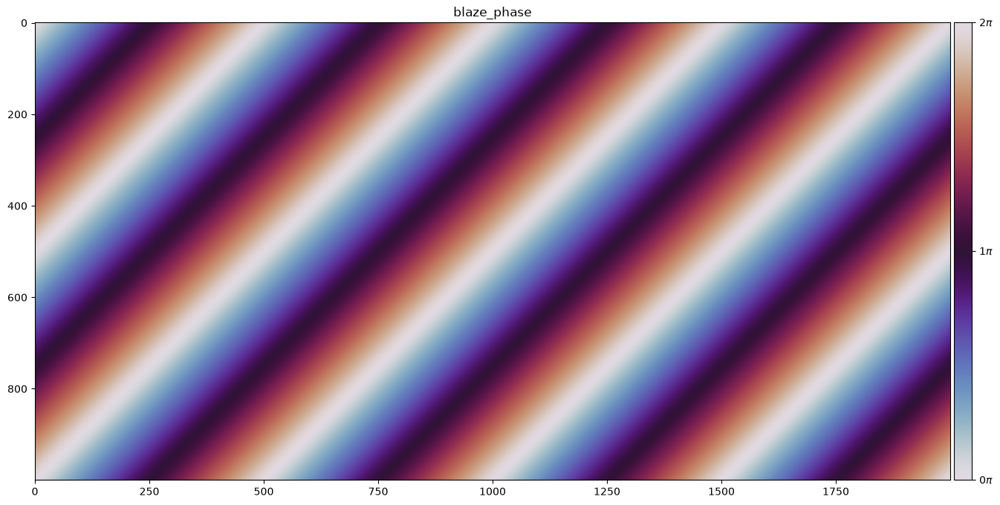

In [5]:
fs.slm.plot(blaze_phase, title="blaze_phase");

However, making and tracking `x_grid` and `y_grid` is an unwieldy pain. We encourage users to _not_ do this unless necessary and instead use convenience features builtin to `blaze` and similar toolbox functions. For instance, we can pass an SLM directly in place of the grids:

[WRN] 21:08:25 FLIR Cam Attempted to set exposure to 0.000162 seconds, but realized 0.00016 seconds.


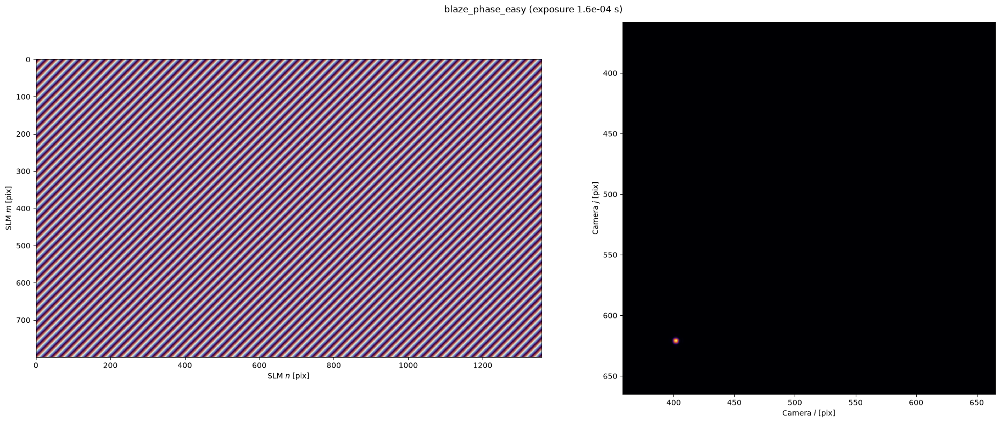

[WRN] 21:08:26 FLIR Cam Attempted to set exposure to 0.000162 seconds, but realized 0.00016 seconds.


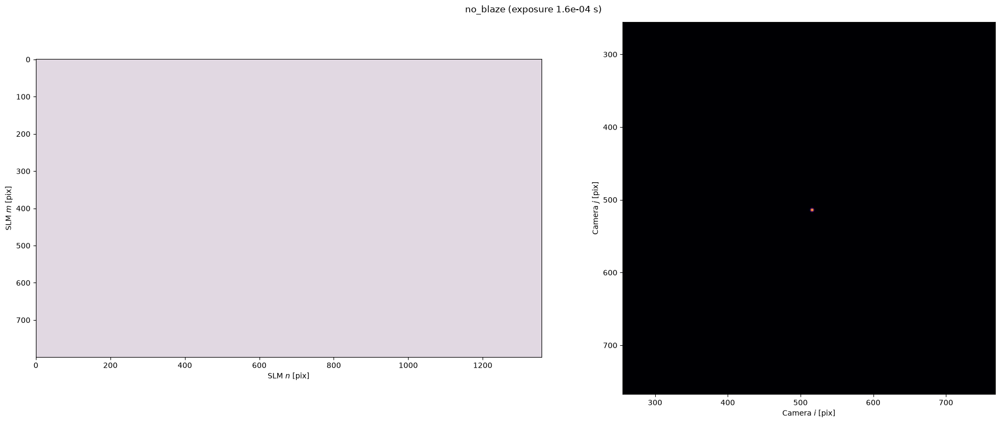

In [6]:
blaze_phase_easy = phase.blaze(
    grid=slm,                       # Coordinates of our SLM pixels, inherited from the SLM.
    vector=(.002, .002)             # Again, angle vector (in normalized units) to blaze towards.
)

# Plotting.
plot(blaze_phase_easy, title="blaze_phase_easy", cam_limits=.3);
plt.show()

no_blaze = phase.blaze(grid=slm, vector=(0,0))
plot(no_blaze, title="no_blaze", cam_limits=.5);

At startup, the SLM caches grids with appropriate `shape` and dimension, using the coordinates normalized to the target wavelength $(\frac{x}{\lambda}, \frac{y}{\lambda})$ which `blaze` expects. These grids are stored in `slm.grid`, and passing `grid=slm` is equivalent to passing `grid=slm.grid`.

Note that these grids are centered on the SLM (more precisely, on the SLM's aperture, which we'll meet in the Zernike section; until then, that is the center of the display), such that when we try other helper functions such as `slmsuite.holography.toolbox.phase.lens`, the result is centered:

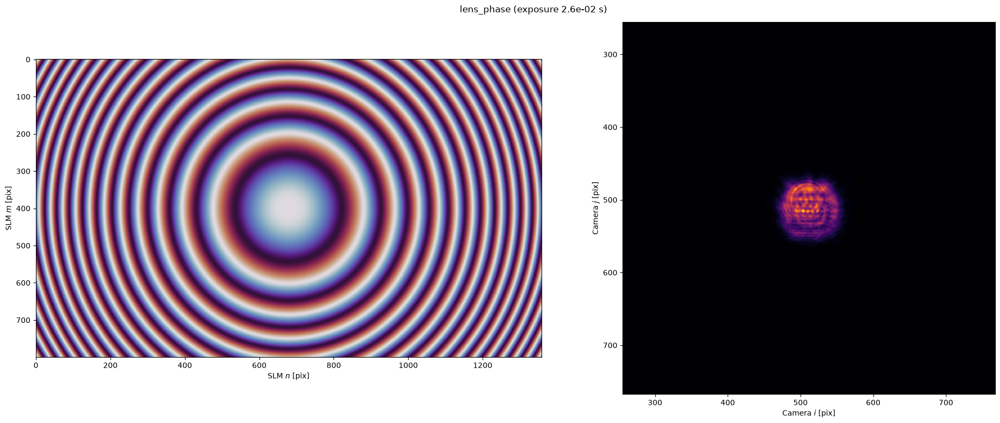

In [7]:
lens_phase = phase.lens(
    grid=slm,
    f=1e7                       # Focal length in wavelengths.
)

plot(lens_phase, title="lens_phase", cam_limits=.5);

As before, units are normalized to wavelength, so passing `f=1e7` is equivalent to requesting a lens with a focal length of ten million wavelengths, or 4.88 meters at our 488 nm wavelength.

The resulting defocused pattern is an image of the SLM's amplitude distribution (see wavefront calibration), in this case cropped above and below by the rectangular SLM. This is an expected result from Fourier optics.

We can of course pass more interesting lenses. For instance, an elliptical lens:

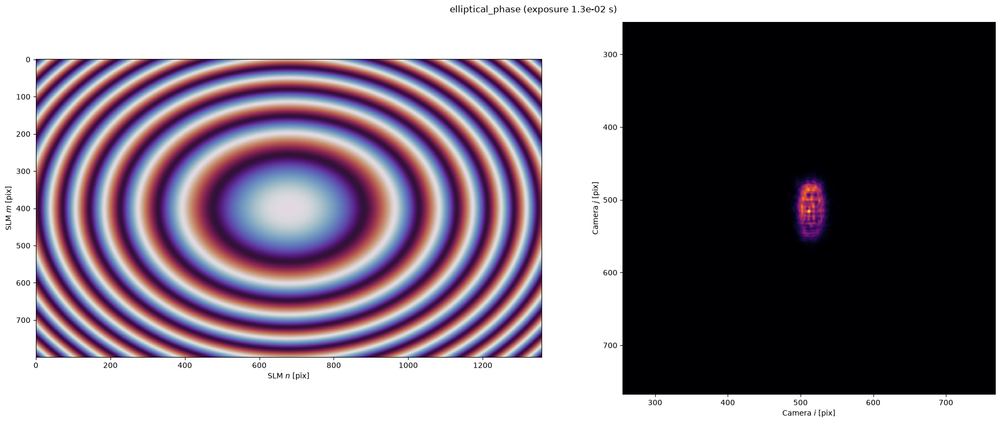

In [8]:
elliptical_phase = phase.lens(
    grid=slm,
    f=(2e7, 1e7)                # Focal length in the x and y directions.
)

plot(elliptical_phase, title="elliptical_phase", cam_limits=.5);

Or going further to a cylindrical lens:

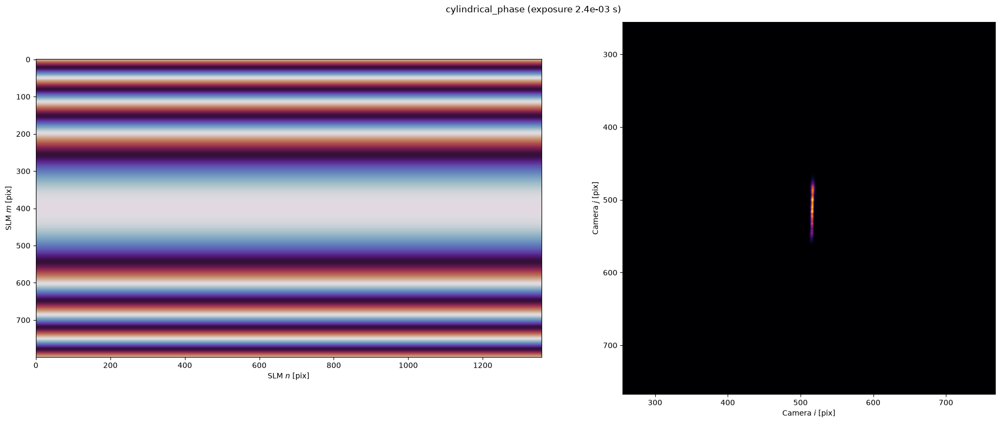

In [9]:
cylindrical_phase = phase.lens(
    grid=slm,
    f=(np.inf, 1e7)             # x direction is now unfocused.
)

plot(cylindrical_phase, title="cylindrical_phase", cam_limits=.5);

#### Pattern Basis Transformations

The patterns we looked at thus far have been all centered at the origin. We can use `toolbox.transform_grid()` to rotate and shift the grid that a pattern is computed on.

For instance, we can rotate the lens about the center:

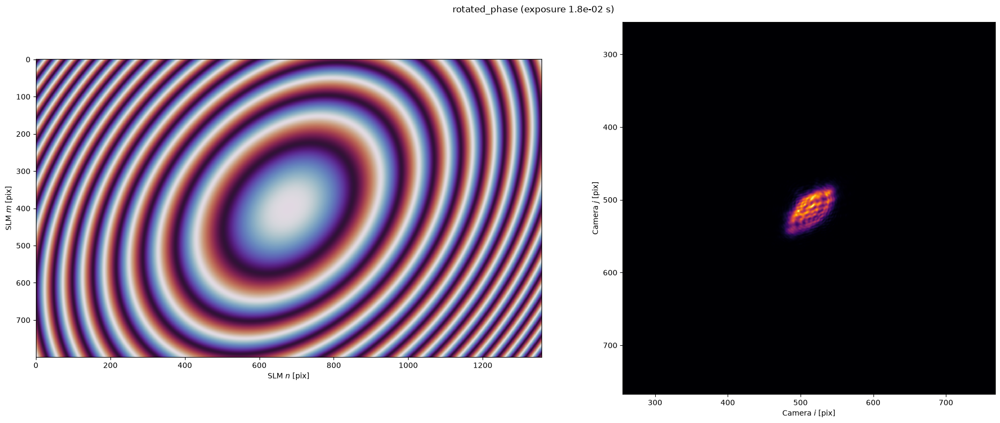

In [10]:
rotated_phase = phase.lens(
    grid=toolbox.transform_grid(
        slm,
        transform=np.pi/4,                  # Angle in radians to rotate by.
        shift=(0, 0)
    ),
    f=(2e7, 1e7)
)

plot(rotated_phase, title="rotated_phase", cam_limits=.5);

Or shift the center across the SLM. Note that center, like other parameters in `slmsuite`, is in normalized units. Fortunately, the `slm` has a helper variable `pitch` which stores the pixel size in normalized units, such that requesting a `(800, -400)` pixel shift is as simple as multiplying by this variable to convert to normalized units:

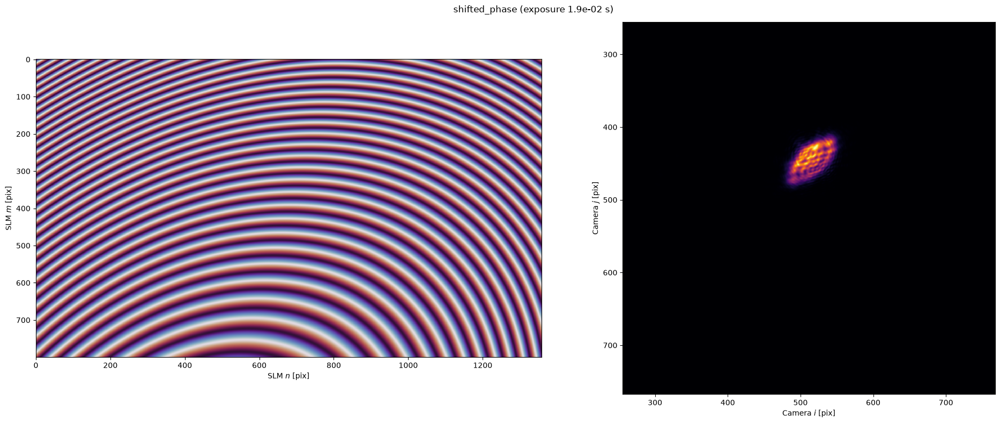

In [11]:
shifted_phase = phase.lens(
    grid=toolbox.transform_grid(
        slm,
        transform=np.pi/4,
        shift=(800*slm.pitch[0], -400*slm.pitch[1])     # Shift of the center of the SLM.
    ),
    f=(2e7, 1e7)
)

plot(shifted_phase, title="shifted_phase", cam_limits=.5);

We can see a slight shift from the zero-th order, the expected result from the amount of linear blaze that is equivalent to shifting the quadratic lens on the SLM.

#### Structured Light Conversion

There are a number interesting optical modes whose farfield pattern is Gaussian in amplitude, with the addition of some phase. As the beam sourced on an SLM is often in a Gaussian mode, we can tune phase on the SLM to produce structured light in the nearfield of the camera. One example is a [Laguerre-Gaussian](https://en.wikipedia.org/wiki/Gaussian_beam#Laguerre-Gaussian_modes) mode, possessing the optical analog of [orbital angular momentum](https://en.wikipedia.org/wiki/Azimuthal_quantum_number). To start, we can take a look at the phase for a $LG_{lp} = LG_{10}$ mode, also known as a [vortex waveplate](https://en.wikipedia.org/wiki/Optical_vortex) (this pattern is hard to see on the camera because the resulting ring pattern is small):

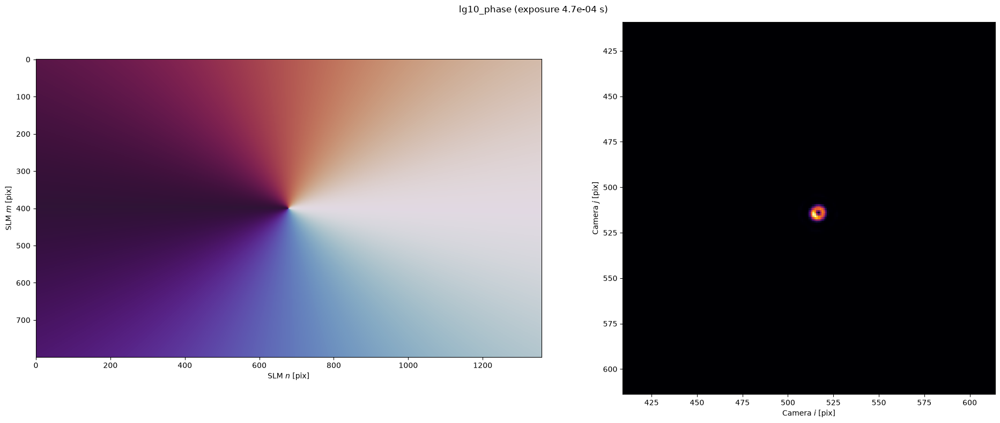

In [12]:
lg10_phase = phase.laguerre_gaussian(
    slm,
    l=1,                                        # Azimuthal wavenumber
    p=0                                         # Radial wavenumber
)

plot(lg10_phase, title="lg10_phase", cam_limits=.2);

Higher order vortex phases such as for a $LG_{lp} = LG_{90}$ mode are easy to see on the camera:

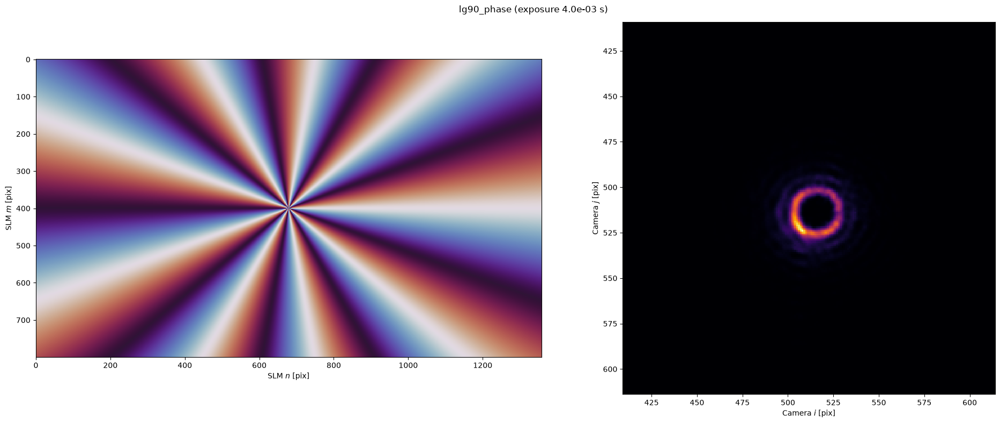

In [13]:
lg90_phase = phase.laguerre_gaussian(
    slm,
    l=9,                                        # A larger azimuthal wavenumber
    p=0
)

plot(lg90_phase, title="lg90_phase", cam_limits=.2);

The asymmetry of the resulting mode is likely due to imperfect centering of the incident beam on the SLM.
Higher order and more interesting modes are also possible, such as for a $LG_{lp} = LG_{93}$ mode.

With a nonzero radial wavenumber $p$, the pattern also depends on the radius `w` of the
incident beam (its $1/e$ amplitude radius), since the radial phase steps are placed relative
to it. If `w` is not given, `slmsuite` uses `slm.source_radius`, which is tied to the SLM's
aperture (see the Zernike section below). Here we choose a beam radius of 100 pixels so that
all three radial rings fit on the SLM:

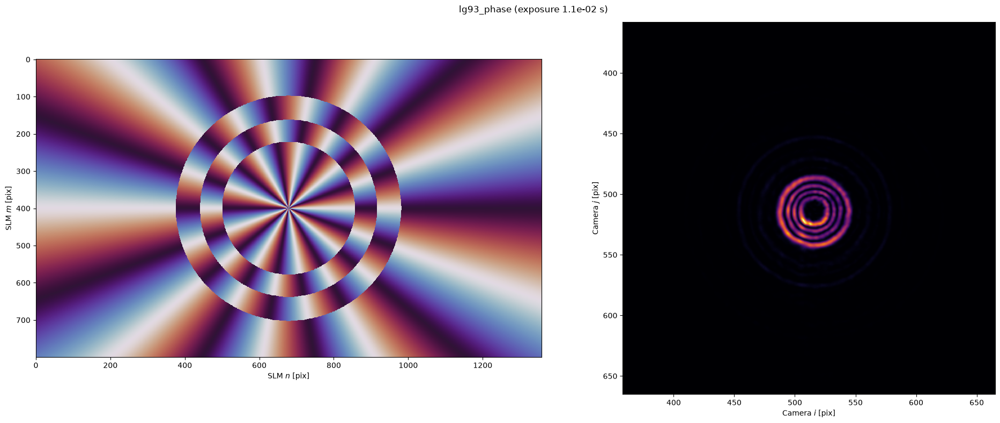

In [14]:
lg93_phase = phase.laguerre_gaussian(
    slm,
    l=9,
    p=3,                                        # Nonzero radial wavenumber
    w=100 * slm.pitch[0]                        # Beam radius: 100 pixels
)

plot(lg93_phase, title="lg93_phase", cam_limits=.3);

We can do cool things like shift the beam by adding a `blaze`.

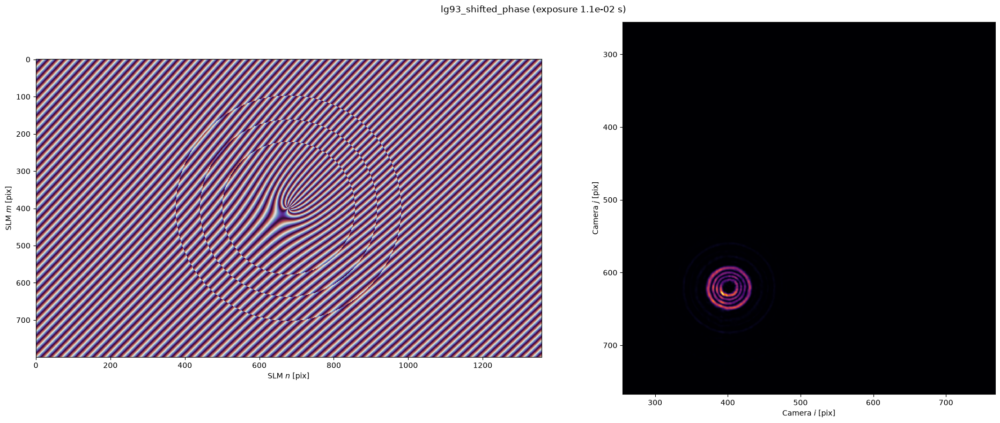

In [15]:
lg93_shifted_phase = lg93_phase + phase.blaze(grid=slm, vector=(.002, .002))

plot(lg93_shifted_phase, title="lg93_shifted_phase", cam_limits=.5);

Or we can defocus the beam by adding a `lens`.

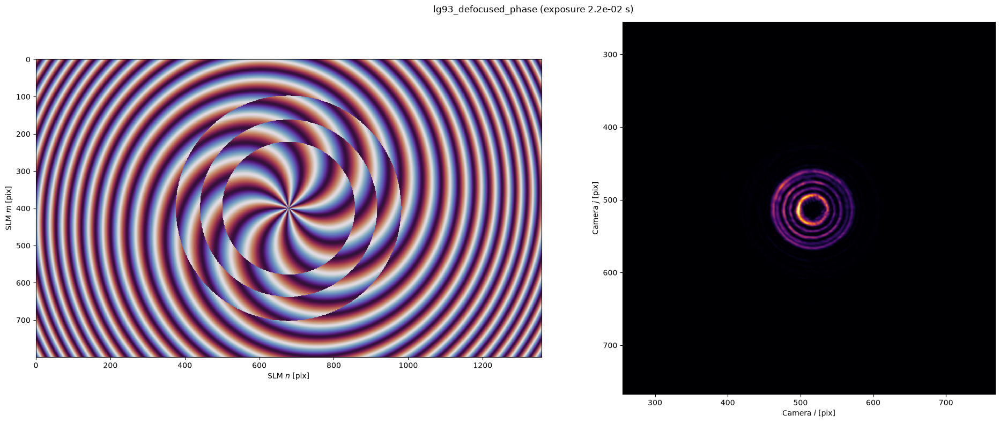

In [16]:
lg93_defocused_phase = lg93_phase + phase.lens(grid=slm, f=1e7)

plot(lg93_defocused_phase, title="lg93_defocused_phase", cam_limits=.5);

We also implement [Hermite-Gaussian](https://en.wikipedia.org/wiki/Gaussian_beam#Hermite-Gaussian_modes) conversion.
Shown below is the phase for a $HG_{nm} = HG_{11}$ mode:

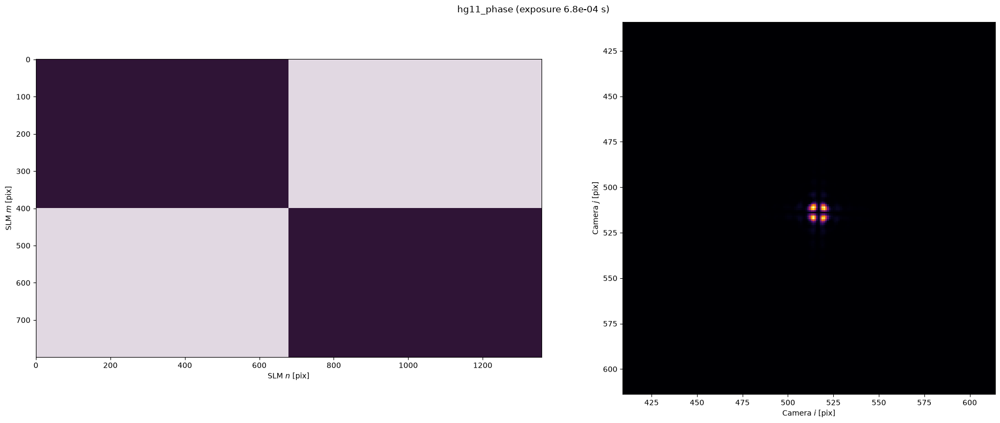

In [17]:
hg11_phase = phase.hermite_gaussian(
    grid=slm,
    n=1,                                        # x wavenumber
    m=1                                         # y wavenumber
)

plot(hg11_phase, title="hg11_phase", cam_limits=.2);

`toolbox.phase` also implements [ince_gaussian()](https://slmsuite.holodyne.com/en/latest/_autosummary/slmsuite.holography.toolbox.phase.ince_gaussian.html), [mathieu_gaussian()](https://slmsuite.holodyne.com/en/latest/_autosummary/slmsuite.holography.toolbox.phase.mathieu_gaussian.html), and [airy()](https://slmsuite.holodyne.com/en/latest/_autosummary/slmsuite.holography.toolbox.phase.airy.html) beam conversions.

#### Segmented SLMs and `imprint`

In some cases, it is desirable to split an SLM into many individual regions. `slmsuite` has helper functions to support this.

The `slmsuite.holography.toolbox.imprint()` operation 'imprints' a function such as `blaze` and `lens` from the previous section onto the SLM, but only in a given window. This window can be defined many ways (see API reference), but here we define it in `(x, w, y, h)` form. Extra keyword arguments to `imprint` are passed to the function. This function is used, for instance, to make the superpixels used for wavefront calibration. See the below examples for three superpixels producing three offset first order diffraction peaks, while most of the field and the zeroth order remain centered.

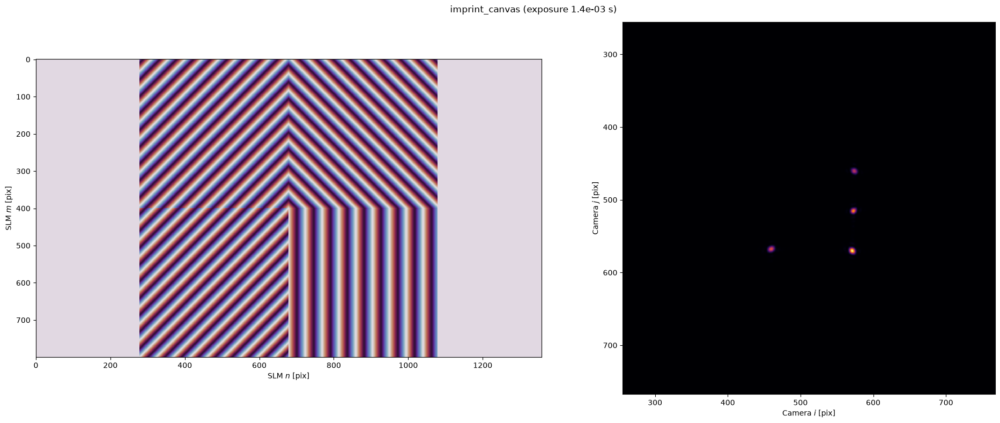

In [18]:
# Setup some parameters for a grid of imprinted blazes.
dk = .001
size = 400
cx1, cy1 = np.flip(slm.shape) // 2
cx0 = cx1 - size
cy0 = cy1 - size

# Setup a blank canvas
canvas = np.zeros(shape=slm.shape)

# Imprint four windows, with different blazes.
toolbox.imprint(canvas, window=[cx0, size, cy0, size], function=phase.blaze, grid=slm, vector=( dk,  dk))
toolbox.imprint(canvas, window=[cx1, size, cy0, size], function=phase.blaze, grid=slm, vector=(-dk,  dk))
toolbox.imprint(canvas, window=[cx0, size, cy1, size], function=phase.blaze, grid=slm, vector=(-dk, -dk))
toolbox.imprint(canvas, window=[cx1, size, cy1, size], function=phase.blaze, grid=slm, vector=(-dk, 0))

plot(canvas, title="imprint_canvas", cam_limits=.5);

`imprint()` supports two operation types:

- `imprint_operation="replace"`, the default, where the original phase on the `canvas` is overwritten, and
- `imprint_operation="add"`, where the original phase is instead added to.

In the example below, phase in the middle window is zeroed, as the field had the negative of the imprinted phase. The right box adds to create a new vector.

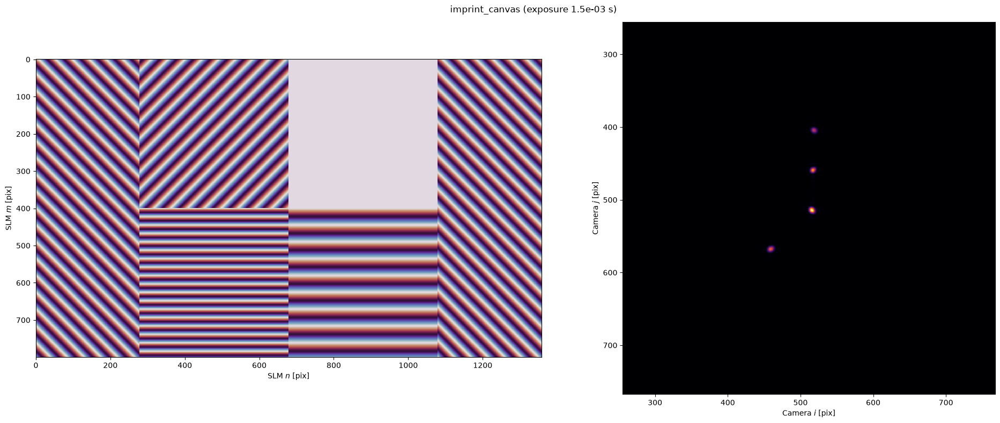

In [19]:
# Use a non-zero base canvas to help explain available operations.
canvas = phase.blaze(grid=slm, vector=(dk, -dk))

# Imprint four windows, now with different operations.
toolbox.imprint(canvas, window=[cx0, size, cy0, size], function=phase.blaze, grid=slm, vector=( dk,  dk), imprint_operation="replace")
toolbox.imprint(canvas, window=[cx1, size, cy0, size], function=phase.blaze, grid=slm, vector=(-dk,  dk), imprint_operation="add")
toolbox.imprint(canvas, window=[cx0, size, cy1, size], function=phase.blaze, grid=slm, vector=(-dk, -dk), imprint_operation="add")
toolbox.imprint(canvas, window=[cx1, size, cy1, size], function=phase.blaze, grid=slm, vector=(-dk, 0),   imprint_operation="add")

plot(canvas, title="imprint_canvas", cam_limits=.5);

Now suppose we want to do something more complicated, with very many regions on the same SLM instead of a handful. As an example, we can make an array of microlenses on a grid. First of all, we have helper functions to construct the grid. The function `toolbox.fit_3pt()` can construct an affine transformation based on three given vectors (`y0`, `y1`, `y2`), and return a grid of vectors with size `N`:

In [20]:
vectors = toolbox.fit_3pt(y0=(200,100), y1=(300,110), y2=(220, 200), N=(10,6))

This is only a fraction of what `toolbox.fit_3pt()` can do; see the API reference for the full capabilities of this function. We can quickly visualize this to see we indeed have a grid:

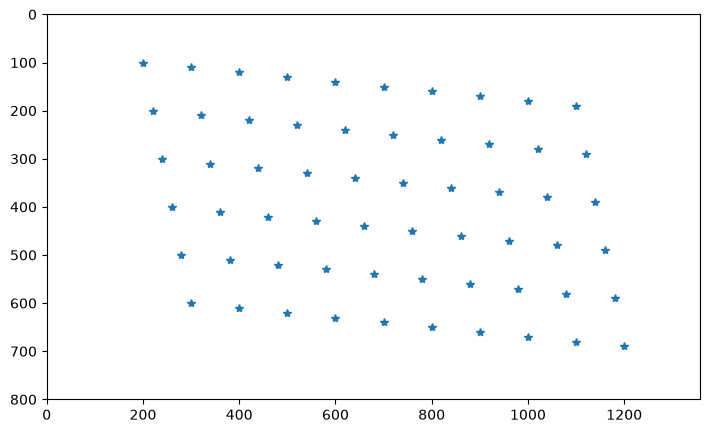

In [21]:
plt.figure(figsize=(10,5))
plt.plot(vectors[0,:], vectors[1,:], "*")       # Plot the points at which cells are desired.
plt.xlim(0, slm.shape[1])
plt.ylim(slm.shape[0], 0)
plt.gca().set_aspect('equal')
plt.show()

Now we can use `imprint` to add a lens at each point. For now we'll use a width and height of `width = 50` pixels. We're also using the `centered` parameter of `imprint` such that the vector position of the window is `centered` instead of at the lower left corner.

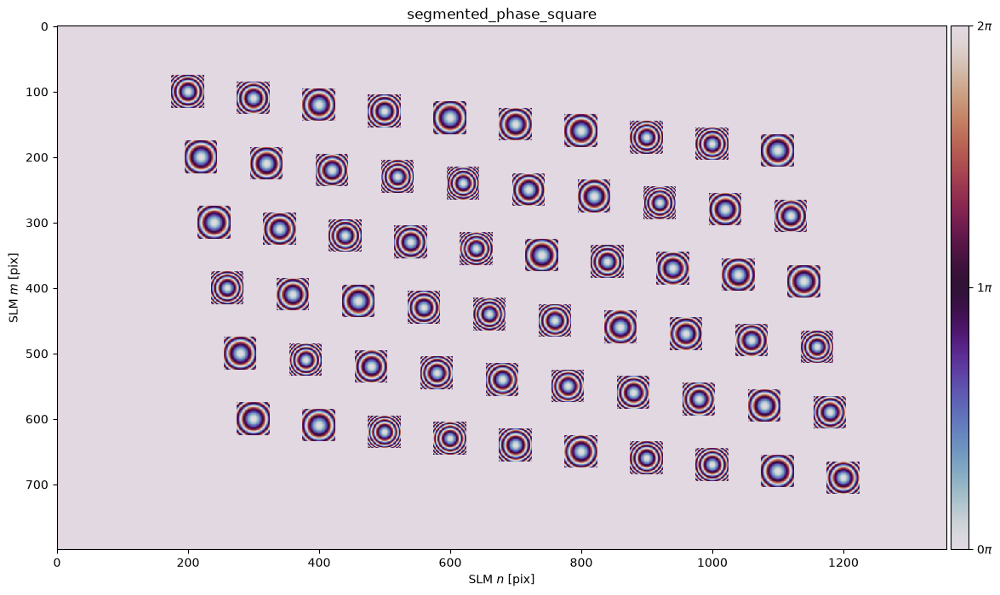

In [22]:
width = 50

def lens_shift(vector):
    # The shift which centers a lens on the pixel at vector: minus that pixel's coordinate in slm.grid.
    x_grid, y_grid = slm.grid
    col, row = int(np.rint(vector[0])), int(np.rint(vector[1]))
    return (-float(x_grid[row, col]), -float(y_grid[row, col]))

def get_segmented_phase_square(width):
    N = vectors.shape[1]
    segmented_phase_square = np.zeros(shape=slm.shape)

    for x in range(N):
        # Imprint a lens in a square window about each point.
        toolbox.imprint(
            segmented_phase_square,
            window=[vectors[0,x], width, vectors[1,x], width],
            function=phase.lens,
            grid=slm,
            f=np.random.uniform(5e4, 1e5),
            shift=lens_shift(vectors[:, x]),
            centered=True
        )

    return segmented_phase_square

fs.slm.plot(get_segmented_phase_square(width), title="segmented_phase_square");

This is interesting, but we should try for better fill factor. We can use another helper
function `toolbox.smallest_distance()` and the Chebyshev metric $\max_i|u_i - v_i|$ to find the largest window
size that doesn't collide with other boxes.

Max width:  90.0


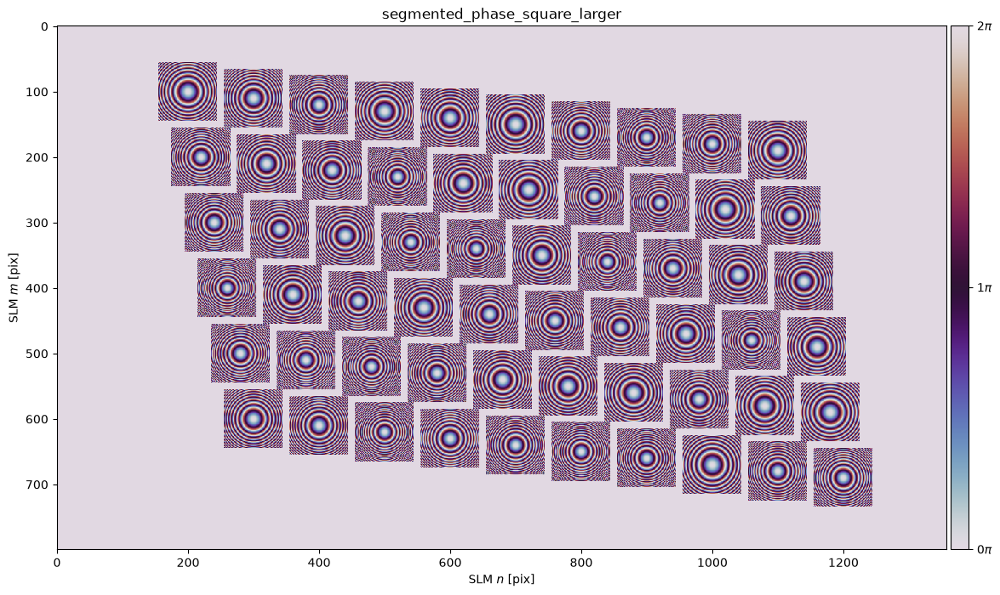

In [23]:
import scipy.spatial.distance as distance

# Find the maximum width that avoids overlapping windows.
width = toolbox.smallest_distance(vectors, metric=distance.chebyshev)
print("Max width: ", width)

fs.slm.plot(get_segmented_phase_square(width), title="segmented_phase_square_larger");

Better, but there's still some empty space that we might want to fill. The helper function `toolbox.voronoi_windows()` can help with this, making a Voronoi cell around each point.

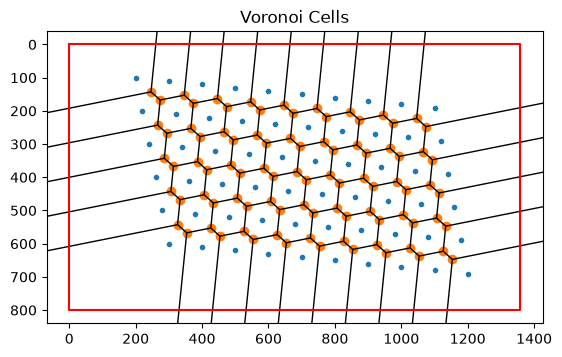

In [24]:
windows = toolbox.voronoi_windows(
    grid=slm.shape,                     # Shape of the canvas of returned boolean windows.
    vectors=vectors,                    # Points to make Voronoi cells around.
    plot=True
)

This function returns a list of windows, where each window is a boolean array.

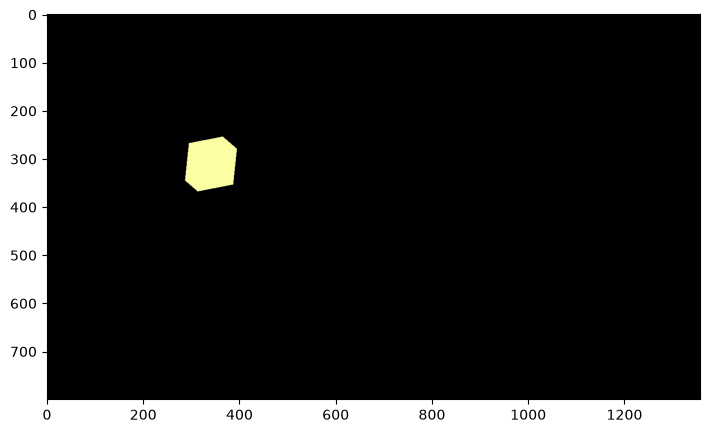

In [25]:
plt.figure(figsize=(10,5))
plt.imshow(windows[21])         # Plot window 21.
plt.show()

Such windows can be passed to `imprint`, where the function will only be evaluated and imprinted within the defined area.

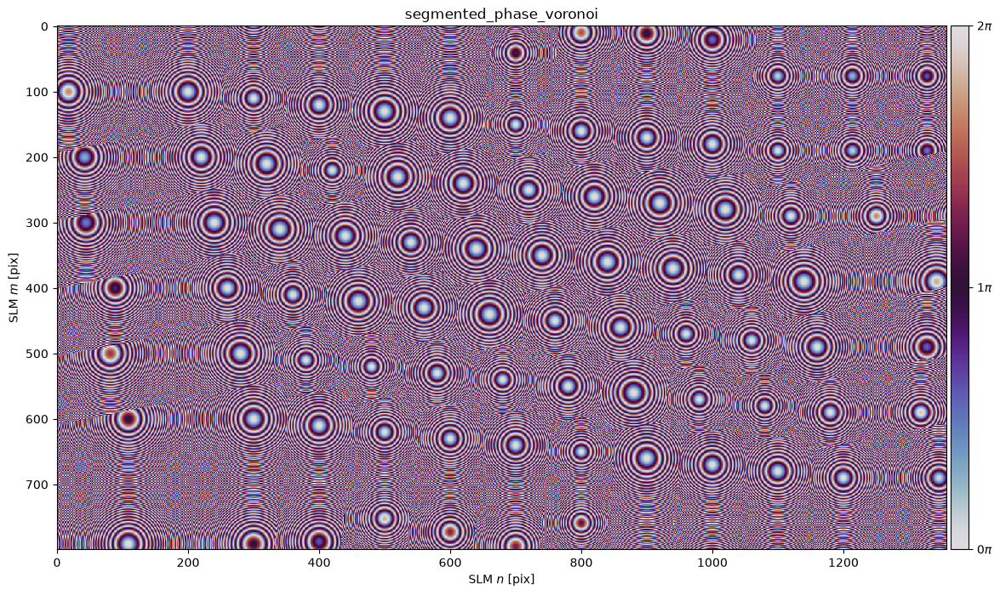

In [26]:
def get_segmented_phase(windows):
    N = vectors.shape[1]
    segmented_phase = np.zeros(shape=slm.shape)

    for x in range(N):
        toolbox.imprint(
            segmented_phase,
            window=windows[x],              # Imprint with each boolean window.
            function=phase.lens,
            grid=slm,
            f=np.random.uniform(5e4, 1e5),
            shift=lens_shift(vectors[:, x])
        )

    return segmented_phase

fs.slm.plot(get_segmented_phase(windows), title="segmented_phase_voronoi");

As a final step, we can use the `radius=` parameter of `voronoi_windows()` clip the edge voronoi cells to more reasonable sizes around the lenses, again using `smallest_distance`.

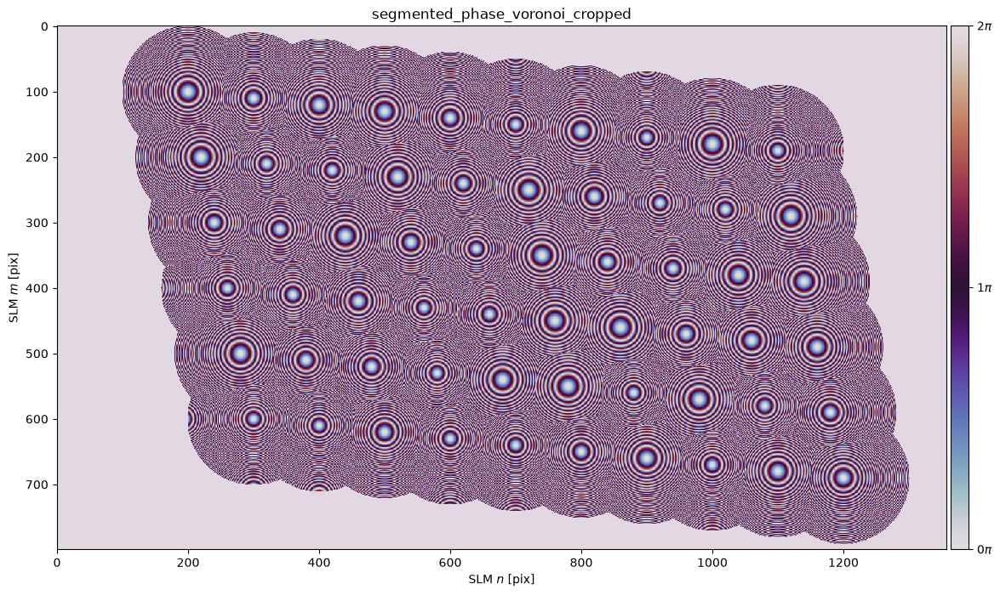

In [27]:
radius = toolbox.smallest_distance(vectors, metric=distance.euclidean)
windows = toolbox.voronoi_windows(
    grid=slm.shape,
    vectors=vectors,
    radius=radius,                  # Additional parameter to crop outside the radius.
    plot=False
)

fs.slm.plot(get_segmented_phase(windows), title="segmented_phase_voronoi_cropped");

#### Zernike Polynomials

[Zernike polynomials](https://en.wikipedia.org/wiki/Zernike_polynomials) are orthogonal functions (usually defined on the unit disk) which are useful as a basis to model or correct aberration.
For instance, the phase correction that we can calculate using wavefront calibration routines in `FourierSLM` can be represented as the sum of a small number of Zernike polynomials. 
The `zernike` function can be used to generate Zernike polynomials, as shown below for $Z_i = Z_5 = Z_2^2 = Z_n^l$.

The [Zernike holography](https://slmsuite.holodyne.com/en/latest/_examples/zernike_holography.html) tutorial provides a more complete introduction to Zernike use in `slmsuite`; here we'll show the very basics to get started.

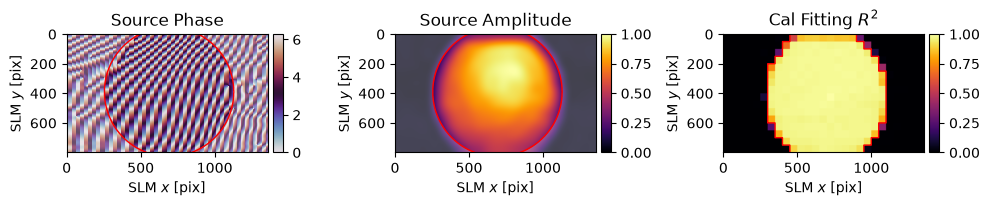

In [28]:
# First set the aperture for Zernike computations using the measured source
slm.fit_aperture()                      
slm.plot_source();

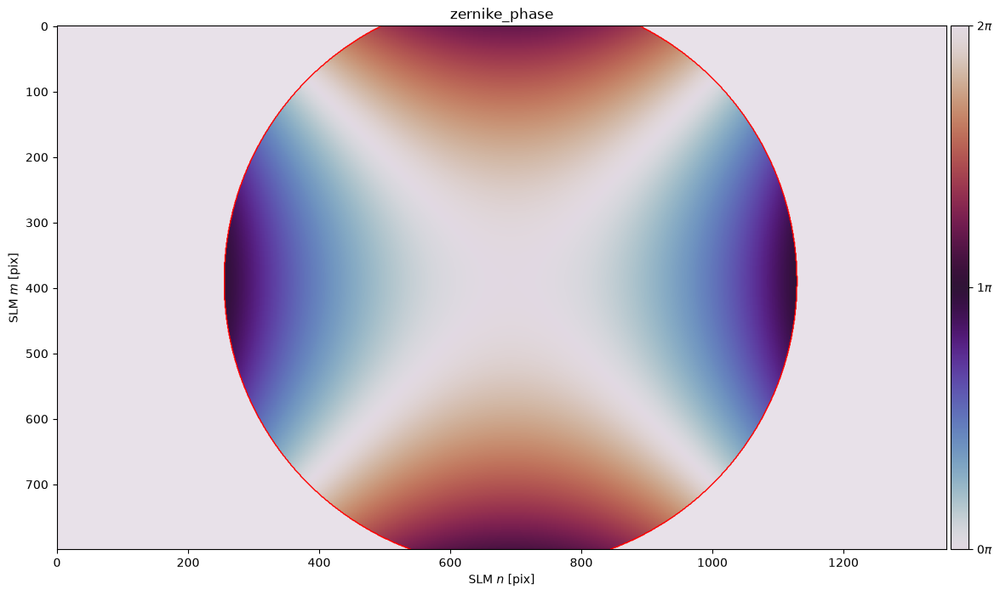

In [29]:
zernike_phase = np.pi * phase.zernike(
    grid=slm,
    index=5,
)

fs.slm.plot(zernike_phase, title="zernike_phase");

The `zernike_sum` function handles summing these basis functions (in a resource-efficient way).

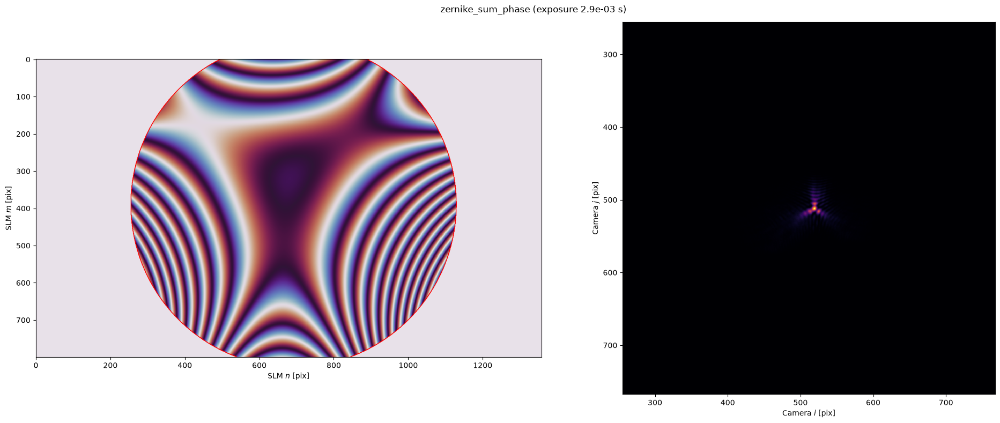

In [30]:
zernike_sum_phase = np.pi * phase.zernike_sum(
    grid=slm,
    indices=(1, 2, 3, 4, 5, 6),
    weights=(1, 1, 2, 3, 5, 8),
)
plot(zernike_sum_phase, title="zernike_sum_phase", cam_limits=.5);

Zernike polynomials are canonically defined on a circular aperture. However, we may
want to use these polynomials on other apertures (e.g. a rectangular SLM).
Cropping this aperture breaks the orthogonality and normalization of the set.
While it is possible to orthonormalize the
cropped set, we do not do so in `slmsuite`, as this is not critical for
applications such as aberration correction for which iterative convergence works well. 
Requesting a `"cropped"` aperture 
circumscribes the shape of the SLM with the circle of the Zernike disk.

The `aperture=` argument chooses the disk:

- `None` uses the SLM's own `slm.aperture` (here, the fitted pupil),
- `"circular"` sizes the disk to the shorter SLM axis,
- `"elliptical"` scales each axis separately, generally producing an ellipse, and
- `"cropped"` sizes the disk to circumscribe the SLM.

A string spec takes its size from the SLM's extent, but stays centered on the SLM's (fitted)
aperture center.

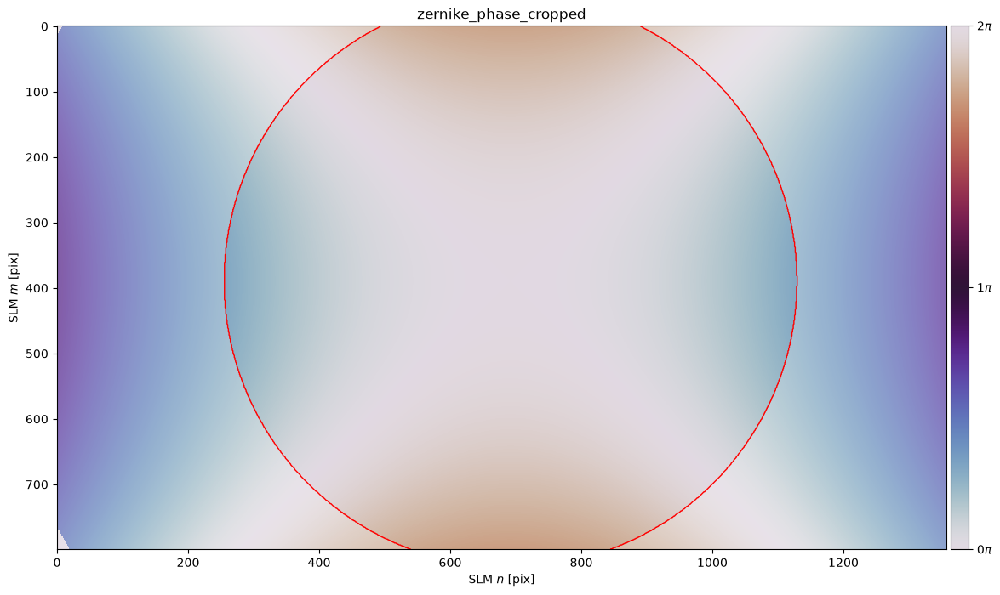

In [31]:
zernike_phase_cropped = np.pi * phase.zernike(
    grid=slm,
    index=5,
    aperture="cropped"                  # Use a cropped aperture.
)

fs.slm.plot(zernike_phase_cropped, title="zernike_phase_cropped");

You can also request the aperture to not be masked with the `use_mask=` option, i.e. to **not** set the phase outside the scaled unit circle to zero.

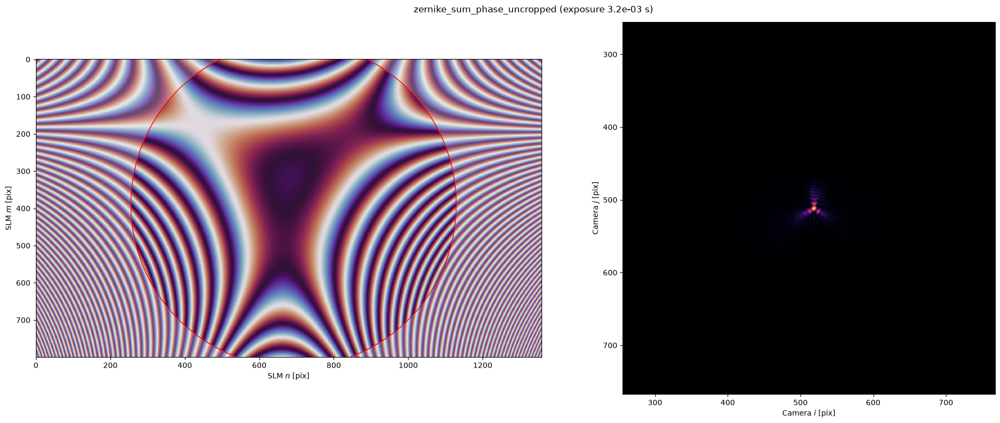

In [32]:
zernike_sum_phase_uncropped = np.pi * phase.zernike_sum(
    grid=slm,
    indices=(1, 2, 3, 4, 5, 6),
    weights=(1, 1, 2, 3, 5, 8),
    aperture=None,                      # The SLM's fitted aperture.
    use_mask=False
)
plot(zernike_sum_phase_uncropped, title="zernike_sum_phase_uncropped", cam_limits=.5);

However, be careful because Zernike polynomials with high order $n$ can diverge according to $r^n$ outside the unit circle.

In [33]:
slm.close()
cam.close()